Customer Default Risk Prediction
Introduction

The aim of this project was to predict whether a customer is likely to default using machine learning. The dataset had 10,000 customer records with financial, personal, and credit-related information.

Data Preprocessing

First, I checked the data for missing values, incorrect categories, and outliers. Missing numerical values were filled using the median. The Bachlors category was corrected to Bachelors. I also created two new features: income_per_dependent and signup_recency_days. Categorical data was one-hot encoded and numerical features were scaled.

Model Results

I tested five models: Logistic Regression, Decision Tree, SVM, Random Forest, and XGBoost.

Model	Accuracy
Logistic Regression	93.45%
Decision Tree	91.80%
SVM	93.95%
Random Forest	94.15%
XGBoost	96.15%

XGBoost gave the highest accuracy among the models tested.

Hyperparameter Tuning

I used GridSearchCV to tune Random Forest and XGBoost. The tuning did not improve the test results compared to the original models. The baseline XGBoost model still performed better with 96.15% accuracy.

Conclusion

Overall, the project helped me understand the complete machine learning process, from cleaning and preparing the data to training and comparing different models. XGBoost performed the best on this dataset with an accuracy of 96.15%.

In [1]:
import numpy as np 
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("synthetic_dataset_10000x20.csv")

Basic checks 

In [4]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


In [5]:
df.tail()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
9995,CUST005735,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,...,HS,Single,East,0,1,2020-02-27,3,0.699,-0.772764,1
9996,CUST005192,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,...,PhD,Divorced,North,0,0,2018-08-23,3,0.435,-0.958924,0
9997,CUST005391,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,...,HS,Married,West,0,0,2019-01-18,4,0.719,-0.916166,0
9998,CUST000861,44,38273.0,18880.0,1060.0,2,653.277645,1000.0,24,11.4,...,Other,Single,North,0,1,2019-08-04,6,0.026,-0.951602,0
9999,CUST007271,30,53614.0,6201.0,1310.0,1,663.975556,5205.0,60,9.8,...,Bachelors,Divorced,North,0,1,2018-03-03,5,0.097,0.141120,1


In [17]:
df.columns

Index(['customer_id', 'age', 'income', 'savings', 'monthly_expenses',
       'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months',
       'employment_years', 'home_ownership', 'education', 'marital_status',
       'region', 'recent_default', 'has_credit_card', 'signup_date',
       'signup_dayofweek', 'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

checking shape and datatypes :

In [7]:
df.shape 

(10000, 21)

In [12]:
df.dtypes

customer_id             object
age                      int64
income                 float64
savings                float64
monthly_expenses       float64
num_dependents           int64
credit_score           float64
loan_amount            float64
loan_term_months         int64
employment_years       float64
home_ownership          object
education               object
marital_status          object
region                  object
recent_default           int64
has_credit_card          int64
signup_date             object
signup_dayofweek         int64
debt_to_income         float64
sin_age                float64
target_default_risk      int64
dtype: object

checking missing values:

In [13]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['education'].unique()

array(['HS', 'Bachelors', 'Masters', 'Other', 'PhD', 'Bachlors'],
      dtype=object)

In [19]:
df["education"].value_counts()

education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64

In [23]:
df["marital_status"].unique()
df['marital_status'].value_counts()

marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64

In [21]:
df["region"].unique()

array(['West', 'East', 'South', 'North'], dtype=object)

In [25]:
df["home_ownership"].unique()
df["home_ownership"].value_counts()

home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64

In [26]:
df.select_dtypes(include="number").columns

Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

In [27]:
df["recent_default"].value_counts()

recent_default
0    9530
1     470
Name: count, dtype: int64

In [28]:
df["has_credit_card"].value_counts()


has_credit_card
1    6948
0    3052
Name: count, dtype: int64

In [29]:
df["target_default_risk"].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

<Axes: >

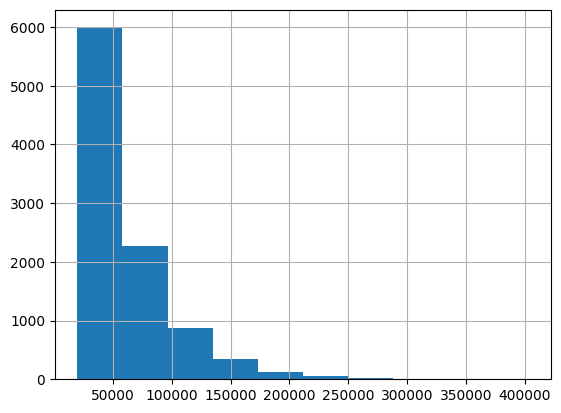

In [30]:
df['income'].hist()

In [32]:
df["income"].dtype

dtype('float64')

In [33]:
df["income"].describe()

count      9682.000000
mean      59712.871411
std       39865.231489
min       20001.000000
25%       31300.500000
50%       47301.500000
75%       75164.250000
max      402769.000000
Name: income, dtype: float64

In [34]:
df["income"].isnull().sum()

np.int64(318)

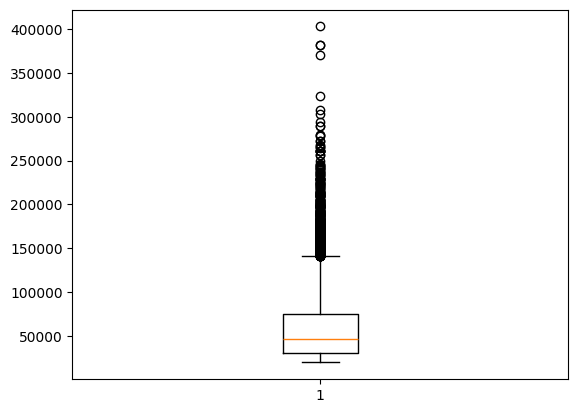

In [35]:
plt.boxplot(df["income"].dropna())
plt.show()

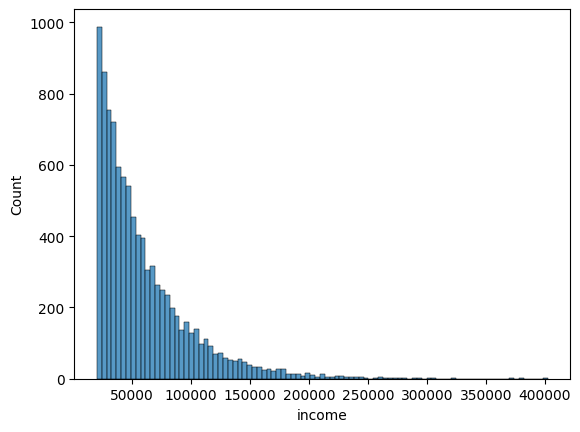

In [49]:
sns.histplot(df["income"])
plt.show()

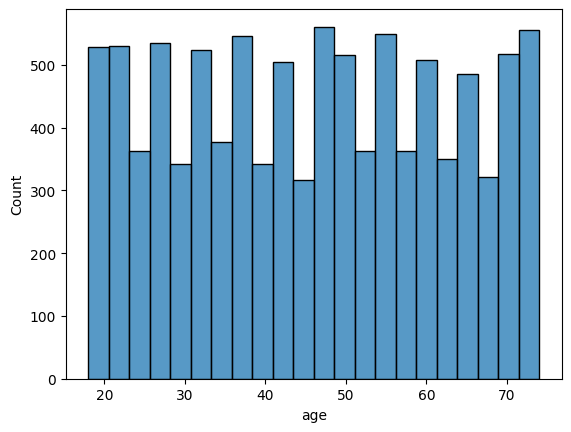

In [51]:
sns.histplot(df["age"])
plt.show()

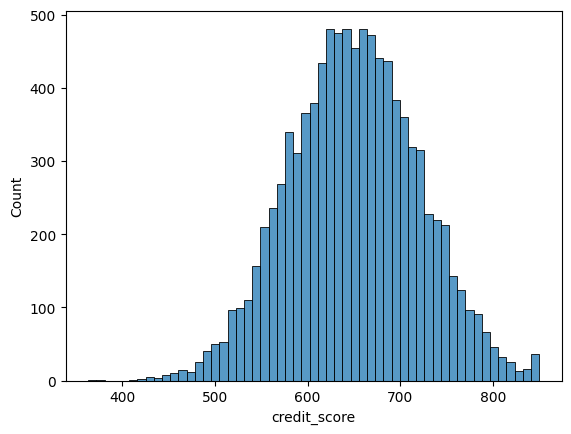

In [52]:
sns.histplot(df["credit_score"])
plt.show()

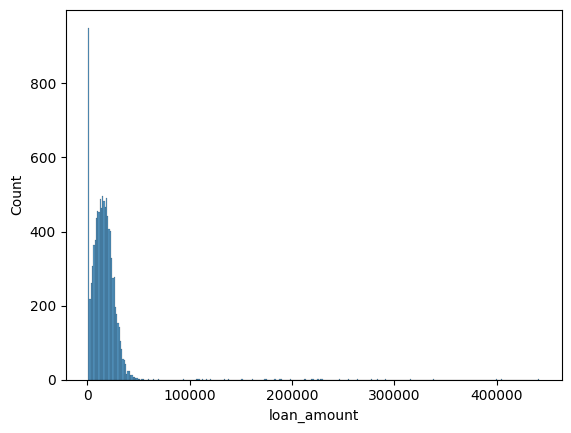

In [53]:
sns.histplot(df["loan_amount"])
plt.show()

<Axes: xlabel='age'>

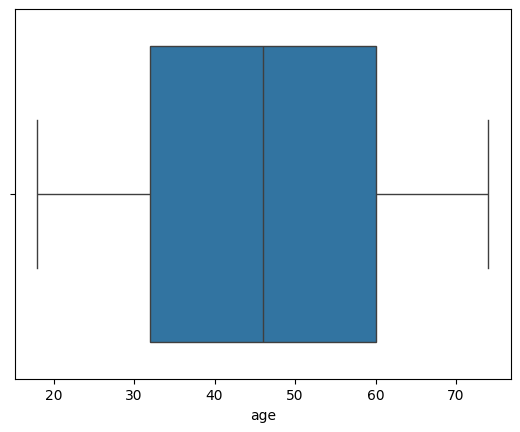

In [54]:
sns.boxplot(x=df["age"])

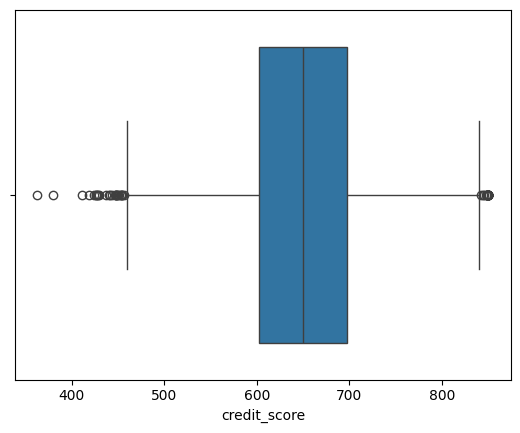

In [57]:
sns.boxplot(x=df['credit_score'])
plt.show()

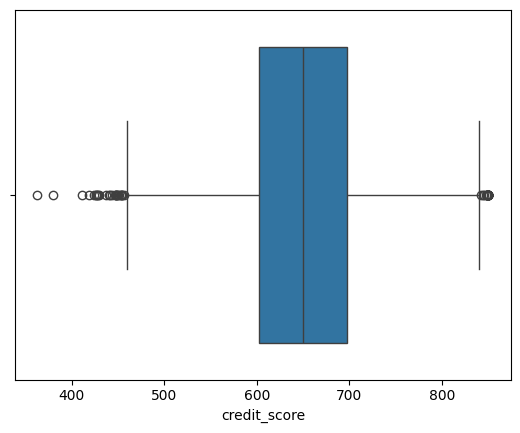

In [59]:
sns.boxplot(x=df['credit_score'])
plt.show()

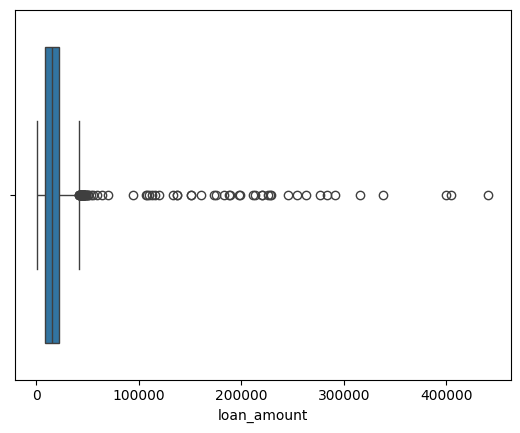

In [60]:
sns.boxplot(x=df["loan_amount"])
plt.show()

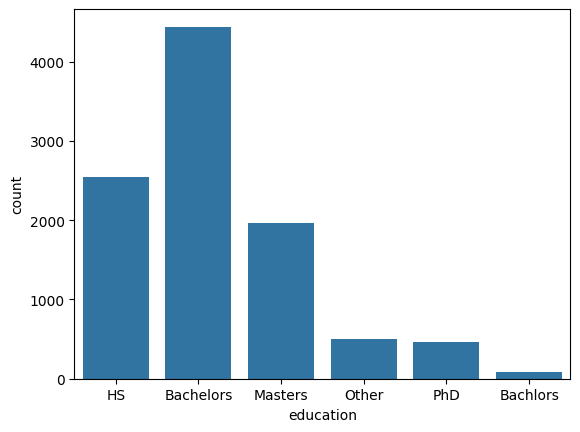

In [61]:
sns.countplot(x="education", data=df)
plt.show()

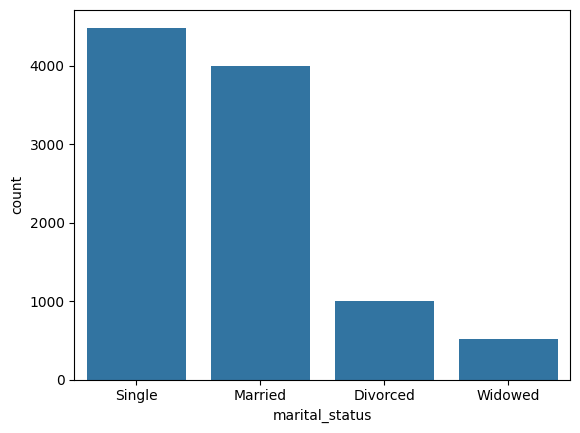

In [62]:
sns.countplot(x="marital_status", data=df)
plt.show()

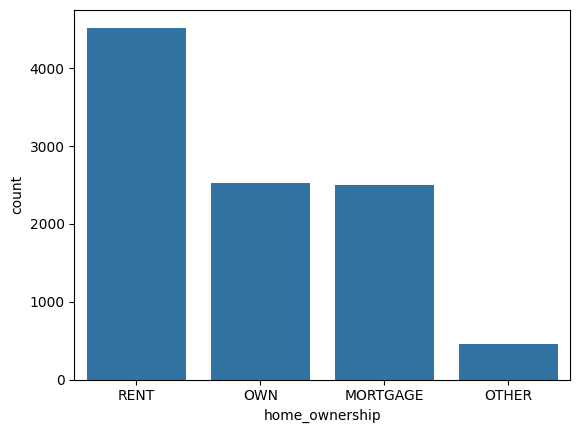

In [63]:
sns.countplot(x="home_ownership", data=df)
plt.show()

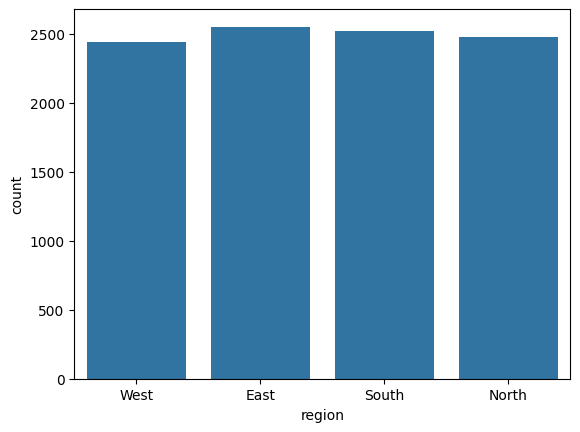

In [64]:
sns.countplot(x="region", data=df)
plt.show()

In [65]:
corr = df.corr(numeric_only=True)

In [66]:
corr

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
age,1.000000,-0.021896,0.000629,-0.001723,0.008063,0.000174,0.003638,-0.004321,0.002142,-0.016766,-0.004703,0.004553,0.026012,-0.112917,-0.032432
income,-0.021896,1.000000,-0.006365,0.005332,0.000688,0.010159,0.017564,0.009695,0.009429,0.001403,0.010843,-0.001875,-0.491136,0.013438,0.637879
savings,0.000629,-0.006365,1.000000,-0.016584,-0.003200,0.010745,-0.015128,-0.001536,0.006753,-0.001630,-0.003141,-0.006597,0.001431,-0.003333,0.004065
monthly_expenses,-0.001723,0.005332,-0.016584,1.000000,0.007482,-0.003548,0.504195,0.001939,0.010845,-0.017124,0.002426,0.000879,-0.000251,0.009825,-0.009883
num_dependents,0.008063,0.000688,-0.003200,0.007482,1.000000,0.000450,-0.000018,0.003700,-0.000246,-0.007105,-0.013172,-0.001237,0.002486,0.000234,-0.006364
credit_score,0.000174,0.010159,0.010745,-0.003548,0.000450,1.000000,0.012001,0.002672,-0.020496,-0.012283,0.003449,0.010511,-0.005296,-0.003400,0.080062
loan_amount,0.003638,0.017564,-0.015128,0.504195,-0.000018,0.012001,1.000000,-0.006549,-0.008021,-0.002742,0.008351,-0.015088,0.426123,-0.004747,-0.005924
loan_term_months,-0.004321,0.009695,-0.001536,0.001939,0.003700,0.002672,-0.006549,1.000000,0.012418,-0.017458,0.015877,-0.002849,-0.016155,0.003195,0.001930
employment_years,0.002142,0.009429,0.006753,0.010845,-0.000246,-0.020496,-0.008021,0.012418,1.000000,0.001828,0.008141,0.009745,-0.009526,-0.022536,0.023547
recent_default,-0.016766,0.001403,-0.001630,-0.017124,-0.007105,-0.012283,-0.002742,-0.017458,0.001828,1.000000,-0.008779,-0.000611,0.011175,0.017490,-0.007756


<Axes: >

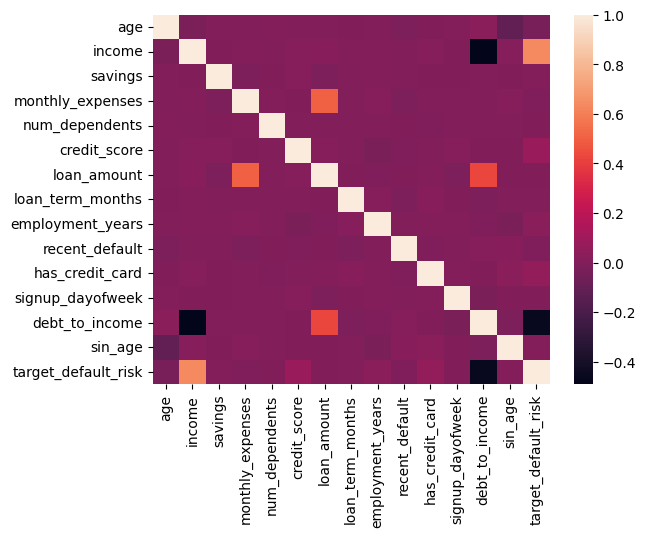

In [67]:
sns.heatmap(corr)

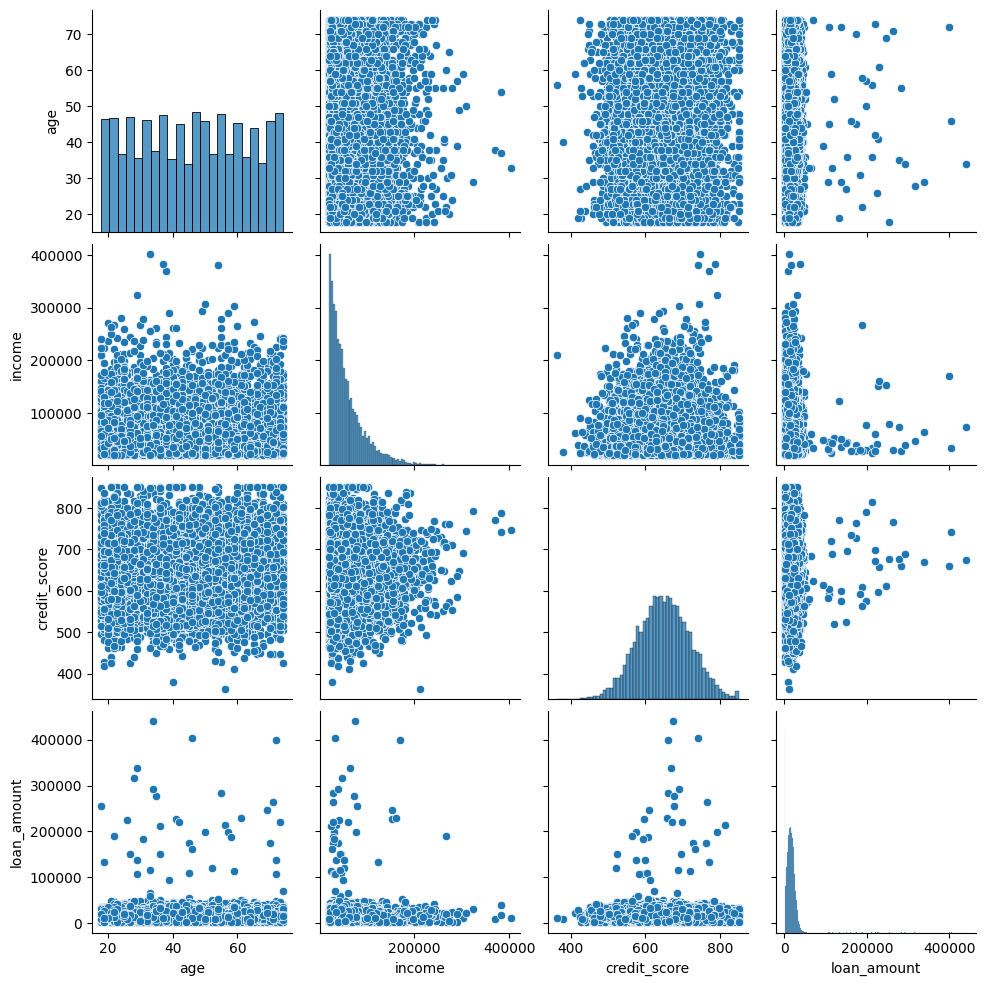

In [68]:
sns.pairplot(df[["age", "income", "credit_score", "loan_amount"]])
plt.show()

In [69]:
df["target_default_risk"].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

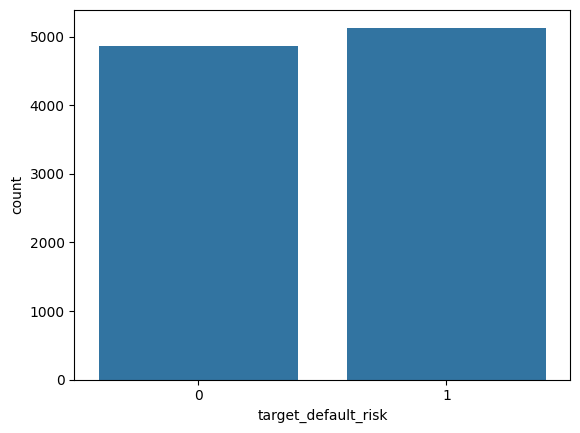

In [70]:
sns.countplot(x="target_default_risk", data=df)
plt.show()

***DATA PREPROCESSING***

In [72]:
#FINDING MISSING VALUES 

In [73]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [74]:
df.isnull().sum()[df.isnull().sum()>0]

income              318
savings             311
monthly_expenses    325
credit_score        326
dtype: int64

In [77]:
numeric_cols=["income","savings","monthly_expenses","credit_score"]
for col in numeric_cols:
    df[col]=df[col].fillna(df[col].median())

In [78]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [79]:
df['education']=df['education'].replace({'Bachlors':'Bachelors'})

In [80]:
df["education"].value_counts()

education
Bachelors    4530
HS           2546
Masters      1962
Other         500
PhD           462
Name: count, dtype: int64

In [81]:
df["income_per_dependent"] = df["income"] / (df["num_dependents"] + 1)

In [82]:
df["income_per_dependent"]

0       22245.666667
1       35370.000000
2       38890.000000
3       14524.500000
4       20021.000000
            ...     
9995    22253.500000
9996     5162.750000
9997    16913.500000
9998    12757.666667
9999    26807.000000
Name: income_per_dependent, Length: 10000, dtype: float64

In [83]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [84]:
df["signup_date"] 

0      2020-07-05
1      2018-10-03
2      2018-05-30
3      2018-04-22
4      2019-12-03
          ...    
9995   2020-02-27
9996   2018-08-23
9997   2019-01-18
9998   2019-08-04
9999   2018-03-03
Name: signup_date, Length: 10000, dtype: datetime64[ns]

In [85]:
df["signup_date"].dtype

dtype('<M8[ns]')

In [86]:
reference_date = pd.Timestamp("2026-09-20")

df["signup_recency_days"] = (
    reference_date - df["signup_date"]
).dt.days

In [87]:
df[["signup_date", "signup_recency_days"]].head()

,signup_date,signup_recency_days
0,2020-07-05,2268
1,2018-10-03,2909
2,2018-05-30,3035
3,2018-04-22,3073
4,2019-12-03,2483


In [88]:
df["income"].describe()

count     10000.000000
mean      59318.189800
std       39286.602573
min       20001.000000
25%       31753.750000
50%       47301.500000
75%       73914.000000
max      402769.000000
Name: income, dtype: float64

In [89]:
q1 = np.percentile(df["income"], 25)
q3 = np.percentile(df["income"], 75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -31486.625
Upper bound: 137154.375


In [90]:
df["income"] = np.where(
    df["income"] > upper_bound,
    upper_bound,
    df["income"]
)

In [91]:
df["income"].max()

137154.375

In [92]:
df.select_dtypes(include="object").columns

Index(['customer_id', 'home_ownership', 'education', 'marital_status',
       'region'],
      dtype='object')

In [93]:
df= df.drop("customer_id",axis=1)

In [94]:
categorical_cols = ["home_ownership", "education", "marital_status", "region"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [95]:
df.head()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,...,education_HS,education_Masters,education_Other,education_PhD,marital_status_Married,marital_status_Single,marital_status_Widowed,region_North,region_South,region_West
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,1,...,True,False,False,False,False,True,False,False,False,True
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,0,...,False,False,False,False,True,False,False,False,False,False
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,0,...,False,False,False,False,False,True,False,False,False,False
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,0,...,True,False,False,False,True,False,False,False,True,False
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,0,...,False,True,False,False,False,True,False,False,False,True


In [96]:
df.dtypes

age                                int64
income                           float64
savings                          float64
monthly_expenses                 float64
num_dependents                     int64
credit_score                     float64
loan_amount                      float64
loan_term_months                   int64
employment_years                 float64
recent_default                     int64
has_credit_card                    int64
signup_date               datetime64[ns]
signup_dayofweek                   int64
debt_to_income                   float64
sin_age                          float64
target_default_risk                int64
income_per_dependent             float64
signup_recency_days                int64
home_ownership_OTHER                bool
home_ownership_OWN                  bool
home_ownership_RENT                 bool
education_HS                        bool
education_Masters                   bool
education_Other                     bool
education_PhD   

In [97]:
df = df.drop("signup_date", axis=1)

In [98]:
#Scaling 
X = df.drop("target_default_risk", axis=1)
y = df["target_default_risk"]

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "age",
    "income",
    "savings",
    "monthly_expenses",
    "num_dependents",
    "credit_score",
    "loan_amount",
    "loan_term_months",
    "employment_years",
    "debt_to_income",
    "sin_age",
    "income_per_dependent",
    "signup_recency_days"
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [101]:
X_train[numeric_cols].describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,debt_to_income,sin_age,income_per_dependent,signup_recency_days
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,-8.126833e-17,7.815970e-17,-5.950795e-17,2.531308e-17,-7.727152e-17,-1.135980e-15,9.769963e-18,-4.618528e-17,7.815970e-17,5.329071e-18,1.776357e-18,1.016964e-16,-1.612044e-16
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.683513e+00,-1.141795e+00,-9.935374e-01,-1.402115e+00,-1.089226e+00,-4.155890e+00,-9.421019e-01,-2.166678e+00,-1.583786e+00,-1.171079e+00,-1.350156e+00,-1.027395e+00,-1.733563e+00
25%,-8.357043e-01,-7.827857e-01,-6.938983e-01,-4.328323e-01,-1.089226e+00,-6.665544e-01,-4.774192e-01,-6.184979e-01,-7.920432e-01,-7.501444e-01,-9.870695e-01,-6.450401e-01,-8.663037e-01
50%,1.210398e-02,-3.090385e-01,-2.916546e-01,-5.065363e-02,-1.909879e-01,1.205964e-03,-6.892164e-02,1.555921e-01,-8.827197e-02,-2.794931e-01,-9.241351e-02,-3.261363e-01,-1.812420e-02
75%,8.599123e-01,5.133999e-01,3.607313e-01,3.436785e-01,7.072503e-01,6.553447e-01,3.480921e-01,9.296821e-01,6.741468e-01,4.927727e-01,1.007036e+00,2.993047e-01,8.699492e-01
max,1.707721e+00,2.431773e+00,7.961838e+00,1.988621e+01,5.198441e+00,2.903632e+00,2.637111e+01,1.703772e+00,4.720831e+00,5.547302e+00,1.597554e+00,1.090482e+01,1.733739e+00


# Machine Learning Model Training

## Logistic Regression

In [103]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [104]:
y_pred_lr = lr_model.predict(X_test)

In [105]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9345


In [106]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)

Precision: 0.9570990806945863
Recall: 0.9132553606237817
F1 Score: 0.9346633416458853


In [107]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[932  42]
 [ 89 937]]


In [109]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [112]:
y_pred_dt = dt_model.predict(X_test)

In [113]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

Accuracy: 0.918
Precision: 0.9184466019417475
Recall: 0.9220272904483431
F1 Score: 0.9202334630350194


In [114]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[890  84]
 [ 80 946]]


In [119]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [120]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

Accuracy: 0.9395
Precision: 0.9631525076765609
Recall: 0.9171539961013645
F1 Score: 0.9395906140788817


In [121]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

[[938  36]
 [ 85 941]]


In [122]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [123]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

Accuracy: 0.9415
Precision: 0.9558676028084253
Recall: 0.928849902534113
F1 Score: 0.9421651013346515


In [124]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[930  44]
 [ 73 953]]


In [125]:
from xgboost import XGBClassifier

In [126]:
xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [127]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)

Accuracy: 0.9615
Precision: 0.967487684729064
Recall: 0.9571150097465887
F1 Score: 0.9622733953944145


In [128]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[941  33]
 [ 44 982]]


In [129]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_svm,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_svm,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_svm,
        recall_rf,
        recall_xgb
    ],
    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_svm,
        f1_rf,
        f1_xgb
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9345,0.957099,0.913255,0.934663
1,Decision Tree,0.9180,0.918447,0.922027,0.920233
2,SVM,0.9395,0.963153,0.917154,0.939591
3,Random Forest,0.9415,0.955868,0.928850,0.942165
4,XGBoost,0.9615,0.967488,0.957115,0.962273


In [130]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9345,0.9571,0.9133,0.9347
1,Decision Tree,0.9180,0.9184,0.9220,0.9202
2,SVM,0.9395,0.9632,0.9172,0.9396
3,Random Forest,0.9415,0.9559,0.9288,0.9422
4,XGBoost,0.9615,0.9675,0.9571,0.9623


In [131]:
RandomForestClassifier(random_state=42)

RandomForestClassifier(random_state=42)

In [132]:
from sklearn.model_selection import GridSearchCV

In [133]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

In [134]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [135]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [136]:
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1 Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 0.9310176854845367


In [137]:
best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

In [138]:
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest")
print("Accuracy:", accuracy_rf_tuned)
print("Precision:", precision_rf_tuned)
print("Recall:", recall_rf_tuned)
print("F1 Score:", f1_rf_tuned)

Tuned Random Forest
Accuracy: 0.9415
Precision: 0.9558676028084253
Recall: 0.928849902534113
F1 Score: 0.9421651013346515


In [139]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
0.9310176854845367


In [140]:
{
    'max_depth': None,
    'min_samples_split': 2,
    'n_estimators': 100
}

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

In [141]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

In [142]:
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [143]:
grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [144]:
print("Best Parameters:", grid_xgb.best_params_)
print("Best CV F1 Score:", grid_xgb.best_score_)
best_xgb = grid_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost")
print("Accuracy:", accuracy_xgb_tuned)
print("Precision:", precision_xgb_tuned)
print("Recall:", recall_xgb_tuned)
print("F1 Score:", f1_xgb_tuned)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV F1 Score: 0.9482750554401778
Tuned XGBoost
Accuracy: 0.9565
Precision: 0.9634748272458046
Recall: 0.9512670565302144
F1 Score: 0.9573320255026974


In [145]:
tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest - Baseline",
        "Random Forest - Tuned",
        "XGBoost - Baseline",
        "XGBoost - Tuned"
    ],
    "Accuracy": [
        accuracy_rf,
        accuracy_rf_tuned,
        accuracy_xgb,
        accuracy_xgb_tuned
    ],
    "Precision": [
        precision_rf,
        precision_rf_tuned,
        precision_xgb,
        precision_xgb_tuned
    ],
    "Recall": [
        recall_rf,
        recall_rf_tuned,
        recall_xgb,
        recall_xgb_tuned
    ],
    "F1 Score": [
        f1_rf,
        f1_rf_tuned,
        f1_xgb,
        f1_xgb_tuned
    ]
})

tuning_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest - Baseline,0.9415,0.9559,0.9288,0.9422
1,Random Forest - Tuned,0.9415,0.9559,0.9288,0.9422
2,XGBoost - Baseline,0.9615,0.9675,0.9571,0.9623
3,XGBoost - Tuned,0.9565,0.9635,0.9513,0.9573
